

=== Configurações do Modelo Carregado ===
Modelo: Sequential
Input shape: (None, 6, 1)
Output shape: (None, 1)

Janela inicial (últimos 6 meses de 2025):
AM_REFERENCIA  HCLQTCON
   2025-07-01    166067
   2025-08-01    152972
   2025-09-01    174096
   2025-10-01    166081
   2025-11-01    170290
   2025-12-01    182781

Gerando previsões para o período: 2026 a 2035...
Total de meses a prever: 120
  Previstos 12 meses...
  Previstos 24 meses...
  Previstos 36 meses...
  Previstos 48 meses...
  Previstos 60 meses...
  Previstos 72 meses...
  Previstos 84 meses...
  Previstos 96 meses...
  Previstos 108 meses...
  Previstos 120 meses...

✓ Arquivo 'previsoes_futuras_2026_2035.csv' gerado com sucesso.

Primeiras linhas da previsão (2026):
      Data  Valor Previsto
2026-01-01        184702.0
2026-02-01        185887.0
2026-03-01        186731.0
2026-04-01        186941.0
2026-05-01        184715.0
2026-06-01        180311.0
2026-07-01        177406.0
2026-08-01        173567.0
2026-09-0

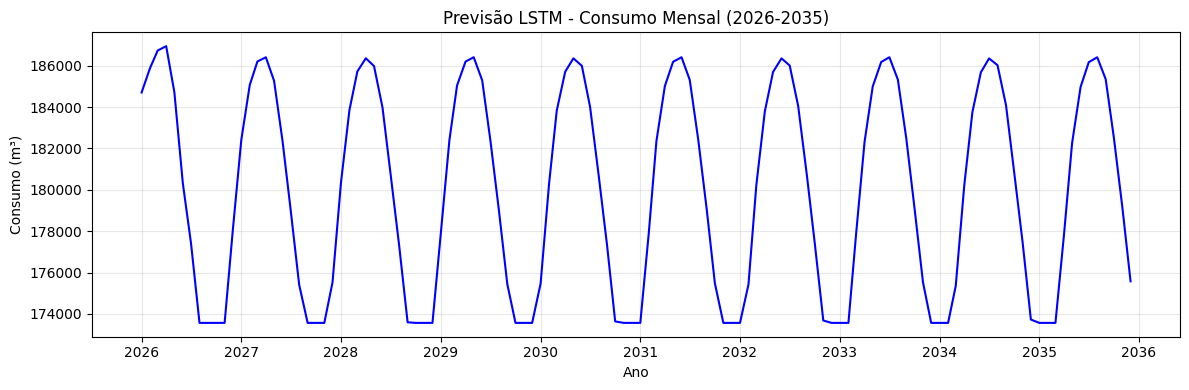

In [1]:
import pandas as pd
import numpy as np
from keras.models import load_model
import joblib
from datetime import datetime
import os

def fazer_previsoes_futuras():
    """
    Gera previsões para o período 2026-2035 usando o modelo LSTM treinado.
    Segue a mesma lógica do script de previsão 2016-2025.
    """
    
    # 1. Carregar modelo e scaler
    model = load_model('best_lstm_model.h5', custom_objects={'mape_loss': lambda y_true, y_pred: 0})
    scaler = joblib.load('scaler_itapua.save')
    
    print("=== Configurações do Modelo Carregado ===")
    print(f"Modelo: {type(model).__name__}")
    print(f"Input shape: {model.input_shape}")
    print(f"Output shape: {model.output_shape}")
    
    # 2. Carregar dados históricos completos (até dezembro/2025)
    path = '..'
    caminho_arquivo = os.path.join(path, 'includes', 'dados', 'Tabela_consumo_Itapua_120m.csv')
    
    if not os.path.exists(caminho_arquivo):
        print(f"Erro: Arquivo não encontrado em {caminho_arquivo}")
        return None
        
    df = pd.read_csv(caminho_arquivo, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    # Agrupar por mês e somar consumo
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    # 3. Definir parâmetros
    look_back = 6  # O modelo usa os últimos 6 meses para prever o próximo
    
    # 4. Obter a "semente" (os 6 meses anteriores a janeiro de 2026)
    # Isso é necessário para gerar a primeira previsão (Jan/2026)
    data_inicio_alvo = pd.to_datetime('2026-01-01')
    dados_semente = df_aggregated[df_aggregated['AM_REFERENCIA'] < data_inicio_alvo].tail(look_back)
    
    if len(dados_semente) < look_back:
        print(f"Erro: Dados históricos insuficientes antes de 2026. Necessário {look_back} meses.")
        print(f"Disponível: {len(dados_semente)} meses")
        return None
    
    print(f"\nJanela inicial (últimos {look_back} meses de 2025):")
    print(dados_semente[['AM_REFERENCIA', 'HCLQTCON']].to_string(index=False))
    
    # Normalizar a janela inicial
    current_window = scaler.transform(dados_semente[['HCLQTCON']]).flatten()
    
    # 5. Criar o intervalo de datas (2026-2035)
    previsao_dates = pd.date_range(start='2026-01-01', end='2035-12-01', freq='MS')
    print(f"\nGerando previsões para o período: {previsao_dates[0].year} a {previsao_dates[-1].year}...")
    print(f"Total de meses a prever: {len(previsao_dates)}")
    
    # 6. Loop de Previsão Recursiva
    lista_previsoes_scaled = []
    
    for i, data in enumerate(previsao_dates):
        # Redimensionar para o formato LSTM: [amostras, timesteps, características]
        x_input = current_window.reshape(1, look_back, 1)
        
        # Prever o próximo ponto
        pred_scaled = model.predict(x_input, verbose=0)
        
        # Guardar o resultado escalado
        lista_previsoes_scaled.append(pred_scaled[0, 0])
        
        # Atualizar a janela: remove o primeiro mês e adiciona a nova previsão no final
        current_window = np.append(current_window[1:], pred_scaled[0, 0])
        
        # Mostrar progresso a cada 12 meses
        if (i + 1) % 12 == 0:
            print(f"  Previstos {i+1} meses...")
    
    # 7. Desnormalizar os resultados para a escala real (Consumo)
    previsoes_finais = scaler.inverse_transform(np.array(lista_previsoes_scaled).reshape(-1, 1)).flatten()
    
    # 8. Organizar e Salvar
    df_resultado = pd.DataFrame({
        'Data': previsao_dates,
        'Valor Previsto': previsoes_finais
    })
    
    # Arredondar para inteiros (como nos dados originais)
    df_resultado['Valor Previsto'] = df_resultado['Valor Previsto'].round(0)
    
    # Salvar CSV
    df_resultado.to_csv('previsoes_futuras_2026_2035.csv', index=False)
    print(f"\n✓ Arquivo 'previsoes_futuras_2026_2035.csv' gerado com sucesso.")
    
    # 9. Exibir amostra das previsões
    print("\nPrimeiras linhas da previsão (2026):")
    print(df_resultado.head(12).to_string(index=False))
    
    print("\nÚltimas linhas da previsão (2035):")
    print(df_resultado.tail(12).to_string(index=False))
    
    # 10. Estatísticas básicas
    print(f"\n--- Estatísticas das Previsões LSTM (2026-2035) ---")
    print(f"Mínimo: {df_resultado['Valor Previsto'].min():.0f} m³")
    print(f"Máximo: {df_resultado['Valor Previsto'].max():.0f} m³")
    print(f"Média: {df_resultado['Valor Previsto'].mean():.0f} m³")
    print(f"Desvio padrão: {df_resultado['Valor Previsto'].std():.0f} m³")
    
    return df_resultado

# Execução
if __name__ == "__main__":
    resultados = fazer_previsoes_futuras()
    
    if resultados is not None:
        print("\n✓ Processo concluído com sucesso!")
        
        # Opcional: plot rápido para verificar
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 4))
        plt.plot(resultados['Data'], resultados['Valor Previsto'], 'b-', linewidth=1.5)
        plt.title('Previsão LSTM - Consumo Mensal (2026-2035)')
        plt.xlabel('Ano')
        plt.ylabel('Consumo (m³)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()